In [1]:
# =============================================================================
# MULTIPLE MYELOMA STAGE PREDICTION — EXPLAINABILITY
# =============================================================================
# This notebook applies SHAP (SHapley Additive exPlanations) to explain
# the predictions of the best model (Random Forest + SMOTE).
#
# SHAP provides both global explanations (which features matter most overall)
# and local explanations (why the model made a specific prediction for
# a specific patient).
#
# This explainability layer is the core contribution of this project,
# connecting directly to clinical interpretability requirements in
# responsible AI for healthcare.
#
# Best model: Random Forest + SMOTE (F1 macro: 0.374)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

shap.initjs()
print("Libraries loaded OK")

Libraries loaded OK


In [2]:
# =============================================================================
# DATA LOADING AND BEST MODEL RECONSTRUCTION
# =============================================================================
# Reload processed dataset and retrain best model (RF + SMOTE)
# to have it available for SHAP analysis.
# =============================================================================

# Load processed dataset
df = pd.read_csv('../data/mm_processed.csv')

# Filter and map to 3-class target
stage_mapping = {
    'IA': 'Stage_I', 'IB': 'Stage_I',
    'IIA': 'Stage_II', 'IIB': 'Stage_II',
    'IIIA': 'Stage_III', 'IIIB': 'Stage_III'
}
df_model = df[df['CLASS_LABEL'].isin(stage_mapping.keys())].copy()
df_model['STAGE'] = df_model['CLASS_LABEL'].map(stage_mapping)

# Prepare features
drop_cols = ['CLASS', 'CLASS_LABEL', 'STAGE']
feature_cols = [c for c in df_model.columns if c not in drop_cols]

df_encoded = df_model.copy()
categorical_cols = df_encoded[feature_cols].select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded[feature_cols]
y = df_encoded['STAGE']

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train best model
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train_smote, y_train_smote)

print(f"Model trained on {X_train_smote.shape[0]} samples (after SMOTE)")
print(f"Target classes: {le_target.classes_}")
print(f"Features: {X.shape[1]}")

Model trained on 348 samples (after SMOTE)
Target classes: ['Stage_I' 'Stage_II' 'Stage_III']
Features: 58


In [3]:
# =============================================================================
# SHAP ANALYSIS — GLOBAL EXPLAINABILITY
# =============================================================================
# TreeExplainer is the most efficient SHAP explainer for tree-based models.
# It computes exact SHAP values using the tree structure.
#
# SHAP values represent the contribution of each feature to the prediction
# for each sample, relative to the expected model output (baseline).
# =============================================================================

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_best)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Classes: {le_target.classes_}")
print("\nComputing SHAP values... OK ✅")

SHAP values shape: (38, 58, 3)
Classes: ['Stage_I' 'Stage_II' 'Stage_III']

Computing SHAP values... OK ✅


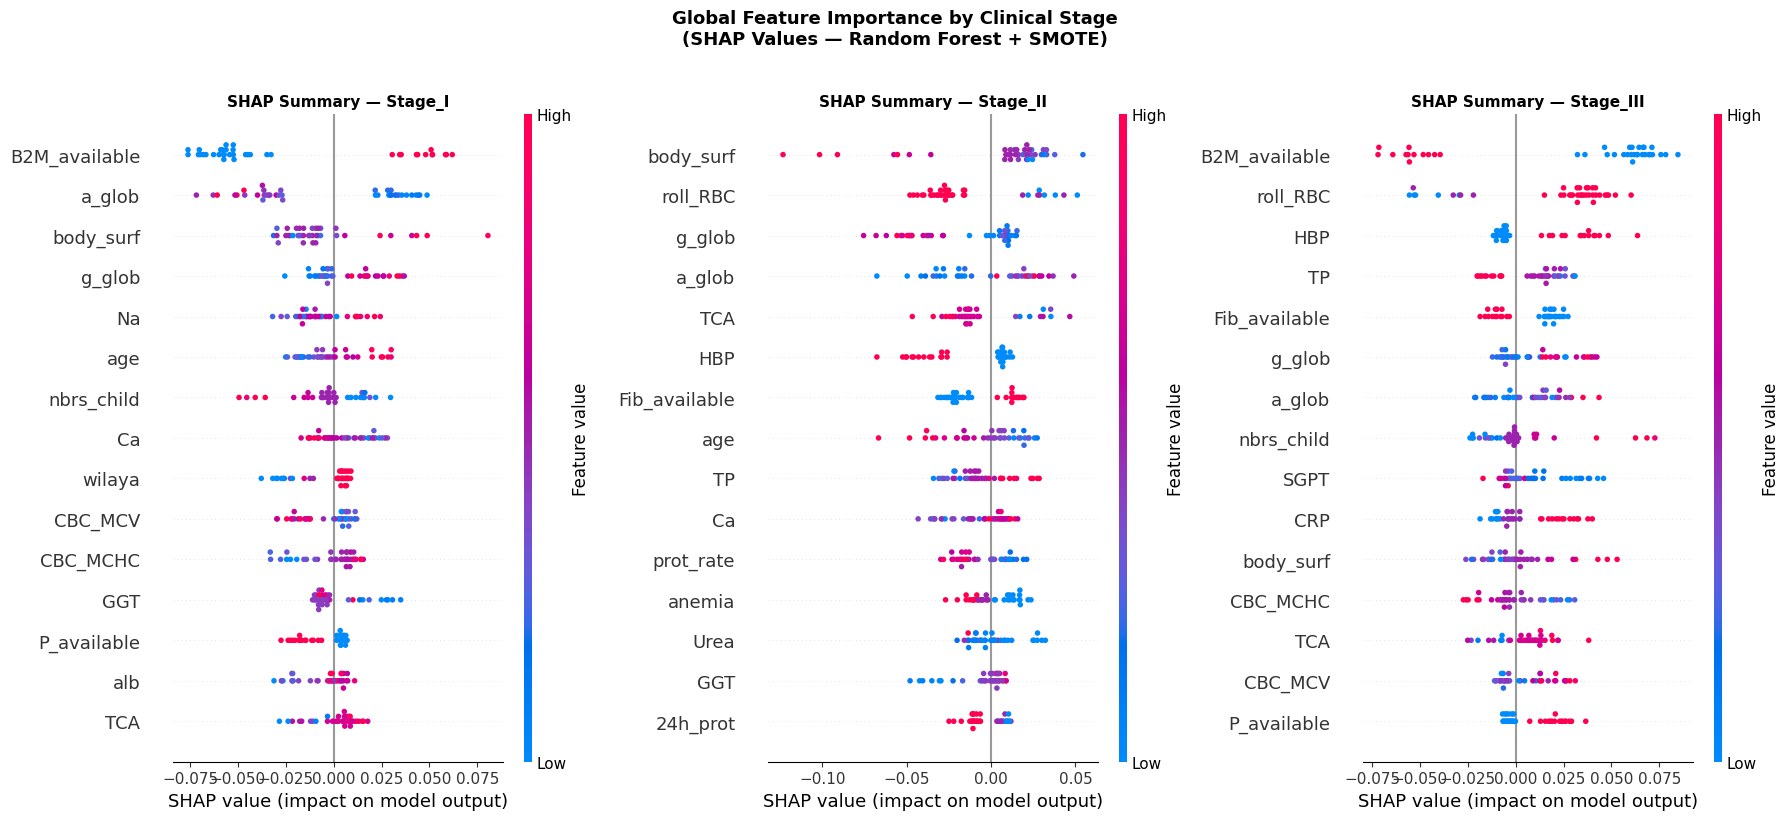

In [4]:
# =============================================================================
# SHAP SUMMARY PLOT — GLOBAL FEATURE IMPORTANCE
# =============================================================================
# The summary plot shows the most important features overall and how their
# values (high/low) affect the prediction for each class.
# Red = high feature value, Blue = low feature value.
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, (cls, ax) in enumerate(zip(le_target.classes_, axes)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        feature_names=feature_cols,
        show=False,
        max_display=15,
        plot_size=None
    )
    ax.set_title(f'SHAP Summary — {cls}', fontweight='bold', fontsize=11)

plt.suptitle('Global Feature Importance by Clinical Stage\n(SHAP Values — Random Forest + SMOTE)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# =============================================================================
# CRITICAL LIMITATION: CLINICAL SELECTION BIAS
# =============================================================================
# B2M_available is the top predictive feature, but this reflects a
# clinical selection bias rather than true predictive power:
# B2M is only measured when the medical team already suspects advanced MM.
#
# This means the model is learning the diagnostic process bias,
# not the underlying disease biology.
#
# Consequence: the model would perform poorly in early detection or
# screening scenarios — precisely where AI could add the most value.
#
# Recommendation for future work: retrain the model excluding
# availability indicators, using only raw biomarker values,
# to assess true biological predictive power.
# =============================================================================
print("Critical limitation documented.")

Critical limitation documented.


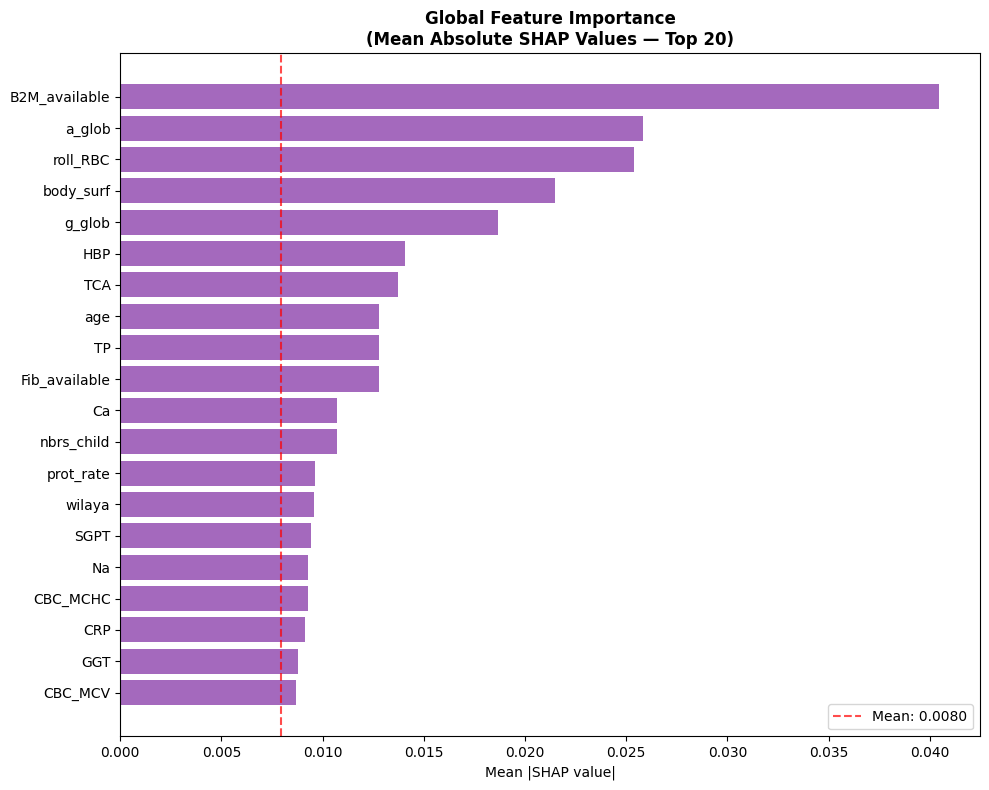


Top 10 most important features:
      feature  importance
B2M_available    0.040457
       a_glob    0.025818
     roll_RBC    0.025363
    body_surf    0.021479
       g_glob    0.018651
          HBP    0.014093
          TCA    0.013745
          age    0.012789
           TP    0.012775
Fib_available    0.012764


In [6]:
# =============================================================================
# SHAP BAR PLOT — GLOBAL FEATURE IMPORTANCE (mean absolute SHAP values)
# =============================================================================
# Mean absolute SHAP values across all samples and classes.
# This gives a single ranked list of the most influential features overall.
# =============================================================================

# Mean absolute SHAP values across all classes
shap_abs_mean = np.abs(shap_values).mean(axis=(0, 2))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': shap_abs_mean
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feature_importance['feature'], 
               feature_importance['importance'],
               color='#8e44ad', alpha=0.8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance\n(Mean Absolute SHAP Values — Top 20)',
             fontweight='bold')
ax.axvline(x=shap_abs_mean.mean(), color='red', linestyle='--', 
           alpha=0.7, label=f'Mean: {shap_abs_mean.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/shap_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 most important features:")
print(feature_importance.tail(10)[['feature', 'importance']].iloc[::-1].to_string(index=False))

In [12]:
# Select one representative patient per stage
stage_indices = {}
for i, cls in enumerate(le_target.classes_):
    idx = np.where(y_test == i)[0][0]
    stage_indices[cls] = idx

print("Selected patients for local explanation:")
for cls, idx in stage_indices.items():
    predicted = le_target.classes_[rf_best.predict(X_test.iloc[[idx]])[0]]
    actual = cls
    correct = "✅" if predicted == actual else "❌"
    print(f"  {cls}: patient index {idx} | predicted: {predicted} {correct}")

Selected patients for local explanation:
  Stage_I: patient index 1 | predicted: Stage_III ❌
  Stage_II: patient index 2 | predicted: Stage_III ❌
  Stage_III: patient index 0 | predicted: Stage_III ✅


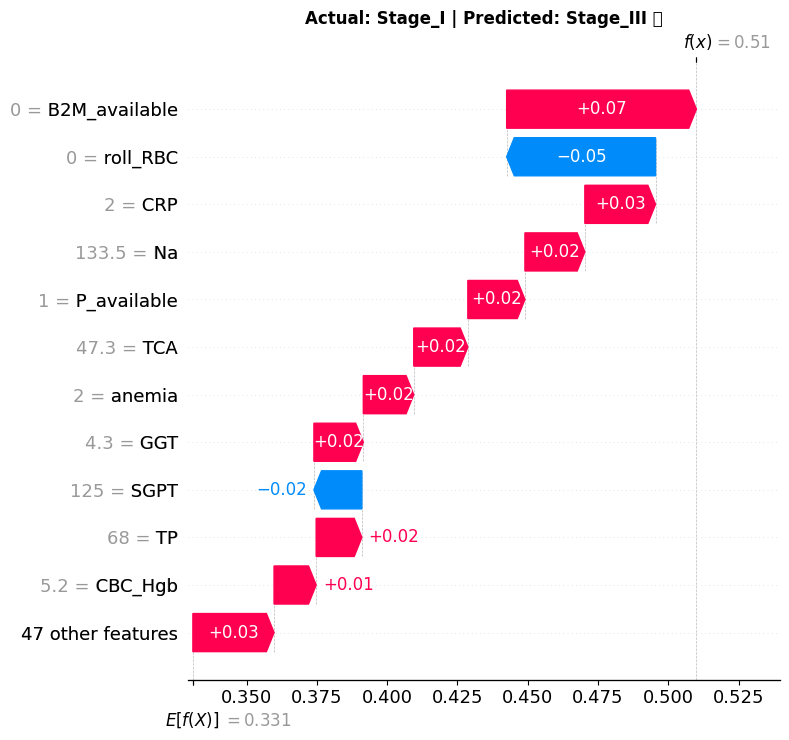

Saved: ../notebooks/shap_waterfall_Stage_I.png


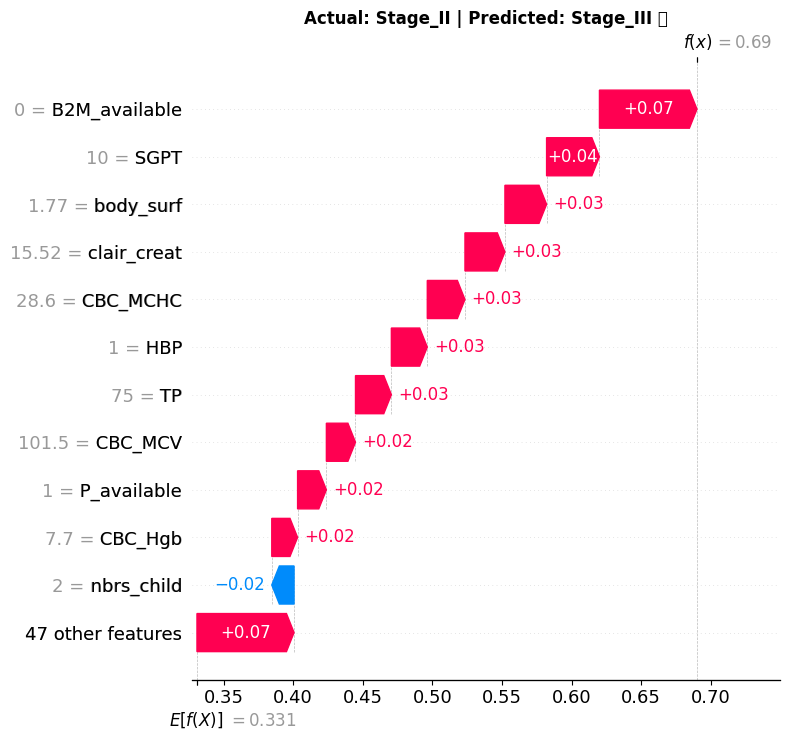

Saved: ../notebooks/shap_waterfall_Stage_II.png


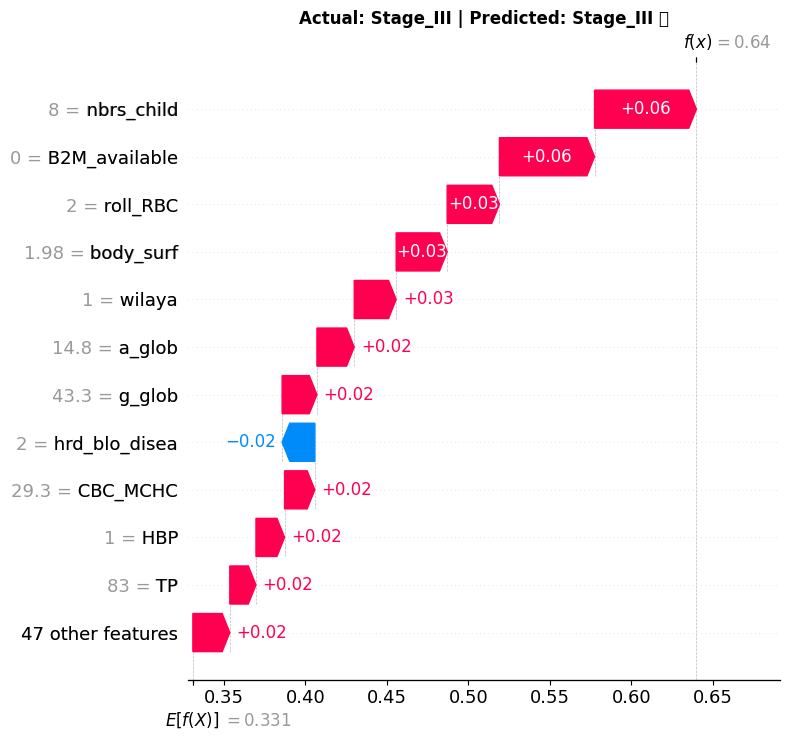

Saved: ../notebooks/shap_waterfall_Stage_III.png


In [18]:
# =============================================================================
# SHAP WATERFALL PLOTS — LOCAL EXPLANATIONS (one plot per patient)
# =============================================================================

for i, (cls, idx) in enumerate(stage_indices.items()):
    
    predicted_class_idx = rf_best.predict(X_test.iloc[[idx]])[0]
    shap_vals_patient = shap_values[idx, :, predicted_class_idx]
    
    explanation = shap.Explanation(
        values=shap_vals_patient,
        base_values=explainer.expected_value[predicted_class_idx],
        data=X_test.iloc[idx].values,
        feature_names=feature_cols
    )
    
    actual = cls
    predicted = le_target.classes_[predicted_class_idx]
    correct = "✅" if predicted == actual else "❌"
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f'Actual: {actual} | Predicted: {predicted} {correct}',
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    path = f'../notebooks/shap_waterfall_{cls}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

In [20]:
# =============================================================================
# LOG SHAP ARTIFACTS TO MLFLOW
# =============================================================================

import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("file:///home/miguel/myeloma-explainability/mlruns")

client = MlflowClient()

# Find the RandomForest_SMOTE run
experiment = client.get_experiment_by_name("mm_stage_prediction")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'RandomForest_SMOTE'"
)
best_run_id = runs[0].info.run_id

# Log SHAP artifacts to the existing run
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact('../notebooks/shap_summary_plot.png', artifact_path="plots/shap")
    mlflow.log_artifact('../notebooks/shap_feature_importance.png', artifact_path="plots/shap")
    for cls in ['Stage_I', 'Stage_II', 'Stage_III']:
        mlflow.log_artifact(f'../notebooks/shap_waterfall_{cls}.png', artifact_path="plots/shap")

print(f"SHAP plots logged to MLflow run: {best_run_id[:8]}...")
print("  ✅ shap_summary_plot.png")
print("  ✅ shap_feature_importance.png")
print("  ✅ shap_waterfall_Stage_I.png")
print("  ✅ shap_waterfall_Stage_II.png")
print("  ✅ shap_waterfall_Stage_III.png")

SHAP plots logged to MLflow run: b70f8ac8...
  ✅ shap_summary_plot.png
  ✅ shap_feature_importance.png
  ✅ shap_waterfall_Stage_I.png
  ✅ shap_waterfall_Stage_II.png
  ✅ shap_waterfall_Stage_III.png
